In [1]:
import matplotlib.pyplot as plt

import microbial_thermo as mt
from microbial_thermo.balance import infer_couples
from microbial_thermo.figures import plot_energy_explorer, plot_half_reactions, plot_redox_tower
from microbial_thermo.supplemental import supplemental_species
entry = supplemental_species()["NH2OH(aq)"]

from microbial_thermo.reaction import Couple, Reaction



In [3]:
from microbial_thermo.reaction import Couple, Reaction

conditions = mt.Conditions(temperature_c=25.0, pH=7)

reaction = Reaction.from_couples(
    donor=Couple.make("H2(aq)", "H+"),
    acceptor=Couple.make(["VOSO4(aq)"], ["VO2+", "SO4-2"], key_element="V"),
    conditions=conditions,
    normalize_to="integer",
)
print(reaction.summary())

Reaction:  2 H+ + H2(aq) + 2 VO2+ + 2 SO4-- -> 2 VOSO4(aq) + 2 H2O
  donor     H+/H2(aq)  (oxidative)  E0' = -0.506 V
  acceptor  VO2+ + SO4--/VOSO4(aq)  (reductive)  E0' = +0.320 V
  n electrons        2
  dE0'               +0.826 V
  dG0'               -159.3 kJ/mol
  dG (conditions)    -159.3 kJ/mol
  dG per electron    -79.7 kJ/mol e-


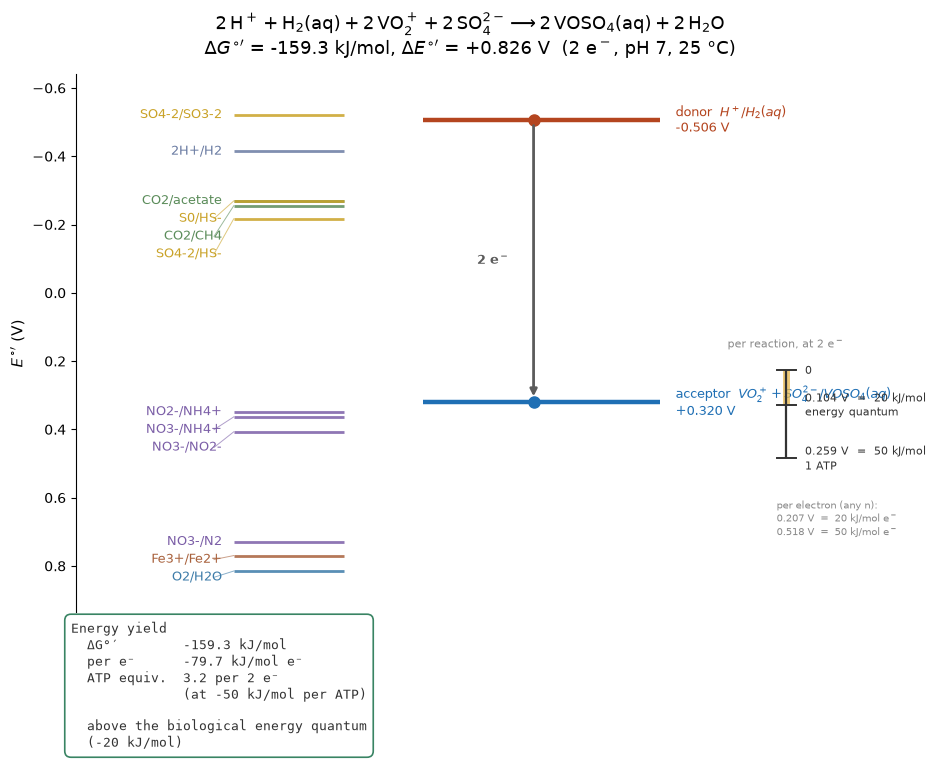

In [4]:
p = plot_redox_tower(reaction)

In [11]:
Reaction:  2 H+ + H2(aq) + 2 VO2+ + 2 SO4-- -> 2 VOSO4(aq) + 2 H2O

((Species(backend='VO2+', formula='VO2+', display='VO_2^+', phase='aq', smiles=None, aliases=('dioxovanadium', 'V(V)')),
  Fraction(1, 1)),
 (Species(backend='SO4--', formula='SO4-2', display='SO_4^{2-}', phase='aq', smiles=None, aliases=('sulfate', 'SO4-2', 'SO42-')),
  Fraction(1, 1)))

In [19]:
Elist = [reaction.acceptor_half.couple.oxidized_side[0][0].backend, 
reaction.acceptor_half.couple.oxidized_side[1][0].backend, 
reaction.acceptor_half.couple.reduced.backend, 
reaction.donor_half.couple.reduced.backend]

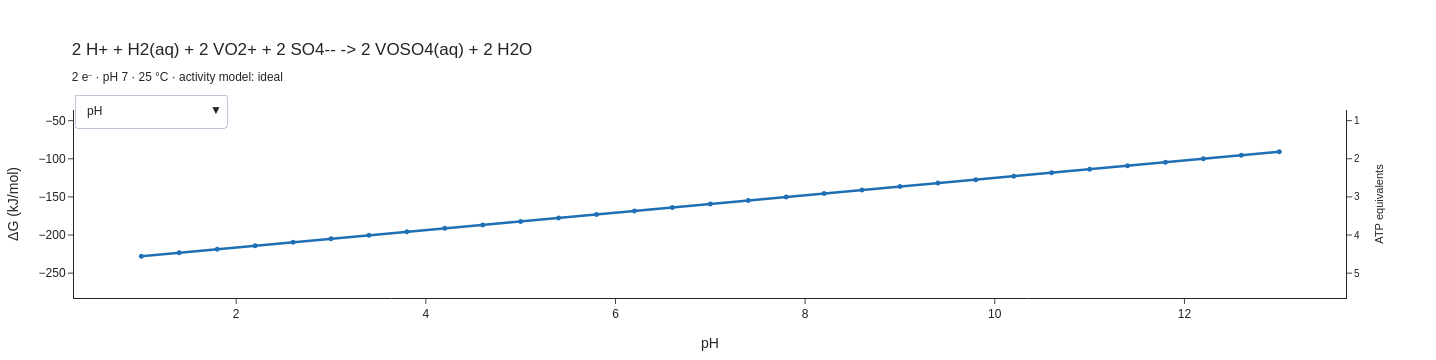

In [20]:
from microbial_thermo.sweep import concentration_axis, partial_pressure_axis, ph_axis

axes = [ph_axis(low=1.0, high=13.0, n=31)] + [concentration_axis(E) for E in Elist]
figure = plot_energy_explorer(reaction, axes=axes)

figure.show()